In [1]:
import pandas as pd

df = pd.read_csv("dataset/processed_data_sim/random_trajectory.csv")
df.head()

C:\Users\Gerso\AppData\Roaming\Python\Python312\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


,vx,vy,omega,vx_cmd,vy_cmd,omega_cmd,filtered_x,filtered_y,x,y,filtered_theta
0,0.0,0.0,0.0,0.0,0.0,0.0,-0.965379,0.536637,-0.965379,0.536637,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,-0.965379,0.536637,-0.965379,0.536637,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,-0.965379,0.536637,-0.965379,0.536637,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,-0.965379,0.536637,-0.965379,0.536637,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,-0.965379,0.536637,-0.965379,0.536637,0.0


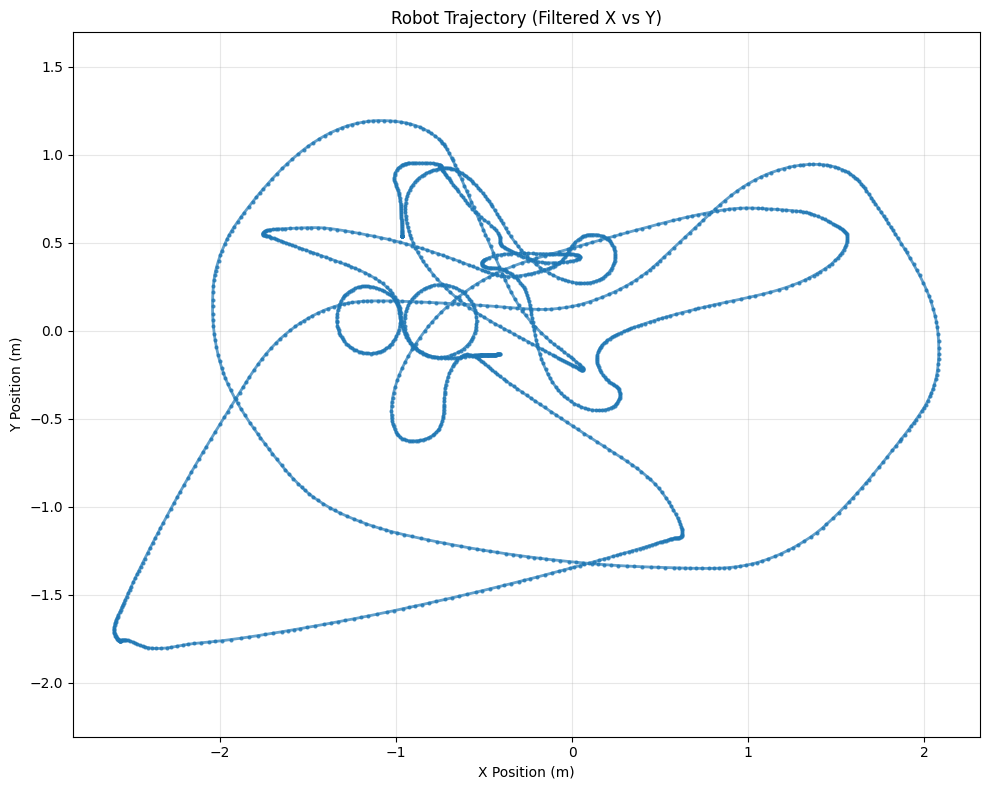

In [2]:
import matplotlib.pyplot as plt
# Create the plot
plt.figure(figsize=(10, 8))
plt.plot(df['filtered_x'], df['filtered_y'], linewidth=2, marker='o', markersize=2, alpha=0.7)
plt.xlabel('X Position (m)')
plt.ylabel('Y Position (m)')
plt.title('Robot Trajectory (Filtered X vs Y)')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.show()

In [9]:
import torch
from torch.utils.data import Dataset
import pandas as pd
from typing import Tuple

from utils.utils import State, Command

class TrajectoryDataset(Dataset):
    def __init__(self, df: pd.DataFrame, window_length: int):
        self.window_length = window_length
        self.num_samples = len(df) - self.window_length + 1
        
        if self.num_samples <= 0:
            raise ValueError(f"DataFrame length must be >= window_length.")

        state_cols = ['filtered_x', 'filtered_y', 'filtered_theta', 'vx', 'vy', 'omega']
        cmd_cols = ['vx_cmd', 'vy_cmd', 'omega_cmd']
        
        self.state_data = torch.tensor(df[state_cols].values, dtype=torch.float32)
        self.cmd_data = torch.tensor(df[cmd_cols].values, dtype=torch.float32)

    def __len__(self) -> int:
        return self.num_samples

    def __getitem__(self, idx: int) -> Tuple[State, Command]:
        """
        Retrieves a sequence of states and commands.
        
        Returns:
            State: Sequence of states where each attribute is shape (window_length,)
            Command: Sequence of commands where each attribute is shape (window_length,)
        """
        end_idx = idx + self.window_length
        
        # Slice raw tensors
        raw_state_seq = self.state_data[idx:end_idx]
        raw_cmd_seq = self.cmd_data[idx:end_idx]
        
        # Convert to structured types
        return State.from_tensor(raw_state_seq), Command.from_tensor(raw_cmd_seq)

In [16]:
from torch.utils.data import DataLoader

window_length = 10
batch_size = 32

dataset = TrajectoryDataset(df, window_length=window_length)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# 3. Iterate through batches during your training loop
for batch_states, batch_cmds in dataloader:
    state_tensor = batch_states.as_tensor()
    cmd_tensor = batch_cmds.as_tensor()
    print(f"State batch shape: {state_tensor.shape}")
    print(f"Command batch shape: {cmd_tensor.shape}")
    break

State batch shape: torch.Size([32, 10, 6])
Command batch shape: torch.Size([32, 10, 3])


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm # For progress bars

class ModelTrainer:
    def __init__(
        self, 
        model: nn.Module, 
        train_loader: DataLoader, 
        val_loader: DataLoader, 
        criterion,
        learning_rate: float = 1e-3, 
        device: str = "cuda" if torch.cuda.is_available() else "cpu"
    ):
        self.device = torch.device(device)
        self.model = model.to(self.device)
        self.train_loader = train_loader
        self.val_loader = val_loader
        
        # Standard regression loss. 
        # Note: Be careful with MSE on the `theta` angle due to the -pi/pi wrap.

        self.criterion = criterion
        
        self.optimizer = optim.Adam(self.model.parameters(), lr=learning_rate)


    def train_epoch(self) -> float:
        self.model.train()
        running_loss = 0.0
        
        # Wrap loader with tqdm for a nice visual progress bar
        pbar = tqdm(self.train_loader, desc="Training")
        
        for state_seq, cmd_seq, target_state in pbar:
            # 1. Move data to device (GPU/CPU)
            state_seq = state_seq.to(self.device)
            cmd_seq = cmd_seq.to(self.device)
            target_state = target_state.to(self.device)
            
            # 2. Zero the gradients
            self.optimizer.zero_grad()
            
            # 3. Forward pass
            predicted_state = self.model(state_seq, cmd_seq)
            
            # 4. Compute loss
            loss = self._calculate_loss(predicted_state, target_state)
            
            # 5. Backward pass and optimization
            loss.backward()
            self.optimizer.step()
            
            running_loss += loss.item()
            pbar.set_postfix({'loss': f"{loss.item():.4f}"})
            
        return running_loss / len(self.train_loader)

    def validate_epoch(self) -> float:
        self.model.eval()
        running_loss = 0.0
        
        # Disable gradient calculation for memory efficiency and speed
        with torch.no_grad():
            for state_seq, cmd_seq, target_state in self.val_loader:
                state_seq = state_seq.to(self.device)
                cmd_seq = cmd_seq.to(self.device)
                target_state = target_state.to(self.device)
                
                predicted_state = self.model(state_seq, cmd_seq)
                loss = self._calculate_loss(predicted_state, target_state)
                
                running_loss += loss.item()
                
        return running_loss / len(self.val_loader)

    def fit(self, epochs: int):
        """Main training loop."""
        print(f"Training on device: {self.device}")
        
        for epoch in range(1, epochs + 1):
            print(f"\n--- Epoch {epoch}/{epochs} ---")
            
            train_loss = self.train_epoch()
            val_loss = self.validate_epoch()
            
            print(f"Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

In [18]:
import torch
from torch.utils.data import DataLoader, random_split

window_length = 10
batch_size = 32

# 1. Instantiate the Dataset with the FULL dataframe first.
# This ensures the internal 10-step sequences are still mathematically valid.
dataset = TrajectoryDataset(df, window_length=window_length)

# 2. Define the split sizes (e.g., 80% train, 20% test)
train_ratio = 0.8
train_size = int(train_ratio * len(dataset))
test_size = len(dataset) - train_size

# 3. Randomly split the dataset
# Passing a generator with a manual seed ensures your split is reproducible 
# if you stop and restart your script.
train_dataset, test_dataset = random_split(
    dataset, 
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# 4. Create the DataLoaders
train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=False 
)

print(f"Total samples: {len(dataset)}")
print(f"Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")

Total samples: 1730
Train batches: 44 | Test batches: 11


In [ ]:
from models.cnn_model import CNNModel

# 1. Initialize your specific model with the dt (time delta)
dt = 0.016  # Example timestep
model = CNNModel(dt=dt)

# 3. Initialize the trainer
trainer = ModelTrainer(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    learning_rate=0.001,
    device="cuda"
)

# 4. Train!
trainer.fit(epochs=50)